# Hospital Readmission Prediction — Exploratory Data Analysis (EDA)

## Project Context
This is the second notebook in the 6-week Hospital Readmission Prediction project. The first notebook (`01_initial_exploration.ipynb`) cleaned the raw dataset and created the binary target variable. This notebook explores the cleaned data to uncover patterns that drive 30-day readmissions.

## Goal of This Notebook
Discover which patient characteristics, conditions, and hospital factors most strongly correlate with 30-day readmission risk. These findings will guide:
- Feature selection for the predictive model (Week 3)
- Dashboard design and stakeholder messaging (Week 4)
- The executive summary's "Key Findings" section (Week 5)

## Notebook Structure
1. **Section 1:** Setup and load cleaned dataset
2. **Section 2:** Univariate analysis — distributions of key features
3. **Section 3:** Bivariate analysis — features vs. readmission target
4. **Section 4:** Top findings summary
5. **Section 5:** Save chart images for use in dashboards and reports

## Five Hypotheses to Test
1. Older patients have higher 30-day readmission rates
2. Patients with longer length of stay are more likely to readmit
3. Patients with more prior emergency visits readmit more frequently
4. Discharge disposition strongly predicts readmission
5. Patients on insulin show different readmission patterns

---

**Author:** Satish Kumar Akrura  
**Date:** May 13, 2026  
**Status:** Day 5 of 6-week project  
**Previous notebook:** `01_initial_exploration.ipynb`

## Section 1: Setup and Data Loading

Load the cleaned dataset created in Notebook 01. Verify the data is intact and ready for analysis.

In [3]:
# Import libraries for analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

# Visualization style
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries loaded")
print(f"  • pandas: {pd.__version__}")
print(f"  • numpy: {np.__version__}")

✓ Libraries loaded
  • pandas: 2.2.2
  • numpy: 1.26.4


In [4]:
# Load the cleaned dataset from data/processed/
df = pd.read_csv('../data/processed/cleaned_data.csv')

print(f"✓ Cleaned dataset loaded")
print(f"  • Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  • Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
print("Target variable distribution:")
print(f"  • Class 0 (NOT readmitted in 30d): {(df['readmitted_30d']==0).sum():,} ({(df['readmitted_30d']==0).mean()*100:.2f}%)")
print(f"  • Class 1 (Readmitted within 30d): {(df['readmitted_30d']==1).sum():,} ({(df['readmitted_30d']==1).mean()*100:.2f}%)")

✓ Cleaned dataset loaded
  • Shape: 98,053 rows × 49 columns
  • Memory: 181.18 MB

Target variable distribution:
  • Class 0 (NOT readmitted in 30d): 86,987 (88.71%)
  • Class 1 (Readmitted within 30d): 11,066 (11.29%)


In [5]:
# Make sure the images folder exists for saving charts
os.makedirs('../images', exist_ok=True)
print("✓ Images folder ready at: ../images/")

✓ Images folder ready at: ../images/


In [6]:
# Make sure the images folder exists for saving charts
os.makedirs('../images', exist_ok=True)
print("✓ Images folder ready at: ../images/")

✓ Images folder ready at: ../images/


## Section 2: Univariate Analysis — Distribution of Key Features

Before examining relationships with readmission, let's understand what the patient population actually looks like. We'll examine the distributions of the most important features:

1. **Age distribution** — testing Hypothesis 1
2. **Length of stay** — testing Hypothesis 2
3. **Prior emergency visits** — testing Hypothesis 3
4. **Primary diagnosis categories** — clinical context
5. **Discharge disposition** — testing Hypothesis 4

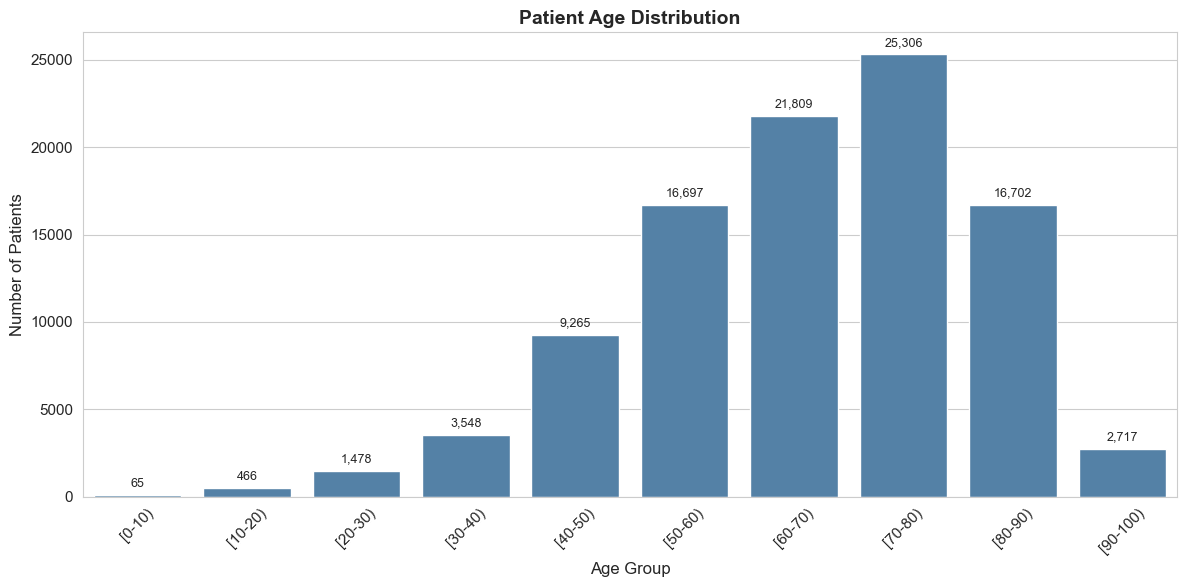


✓ Chart saved to: images/01_age_distribution.png

Key observations:
  • Most common age group: [70-80) (25,306 patients)
  • Total age groups: 10
  • Patients aged 60+: 66,534 (67.9%)


In [8]:
# Chart 1: Distribution of patient ages

# Get age counts in proper order (the age column is text like '[60-70)')
age_counts = df['age'].value_counts().sort_index()

# Create the figure
plt.figure(figsize=(12, 6))

# Build the bar chart
ax = sns.barplot(x=age_counts.index, y=age_counts.values, color='steelblue')

# Add titles and labels
plt.title('Patient Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=45)

# Add count labels above each bar
for i, v in enumerate(age_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# Save the chart to images folder
plt.tight_layout()
plt.savefig('../images/01_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key observations
print(f"\n✓ Chart saved to: images/01_age_distribution.png")
print(f"\nKey observations:")
print(f"  • Most common age group: {age_counts.idxmax()} ({age_counts.max():,} patients)")
print(f"  • Total age groups: {len(age_counts)}")

# Calculate 60+ age group total
older_patients = df[df['age'].isin(['[60-70)', '[70-80)', '[80-90)', '[90-100)'])].shape[0]
print(f"  • Patients aged 60+: {older_patients:,} ({older_patients/len(df)*100:.1f}%)")

### 📊 Finding 1: Patient Population Skews Older

**Observation:** 67.9% of all 98,053 patient encounters are aged 60+, with the **[70-80) age group representing the largest segment** at 25,306 patients (25.8% of total).

**Clinical context:** This older skew reflects the demographics of diabetes patients — type 2 diabetes prevalence rises sharply after age 45, and complications requiring hospitalization typically occur in patients 60+. The dataset under-represents younger adults, who rarely have hospital encounters severe enough to be in this population.

**Implication for the model:**
- Age is likely to be a meaningful predictor
- Will need to engineer `age_midpoint` (numeric) from age brackets in Week 3
- Model performance should be checked across age groups to avoid bias against younger patients (small sample size)

**Implication for the dashboard:**
- Default view should target the 60-80 demographic where most cases live
- Outlier groups ([0-10), [90-100)) need separate handling in segmentation

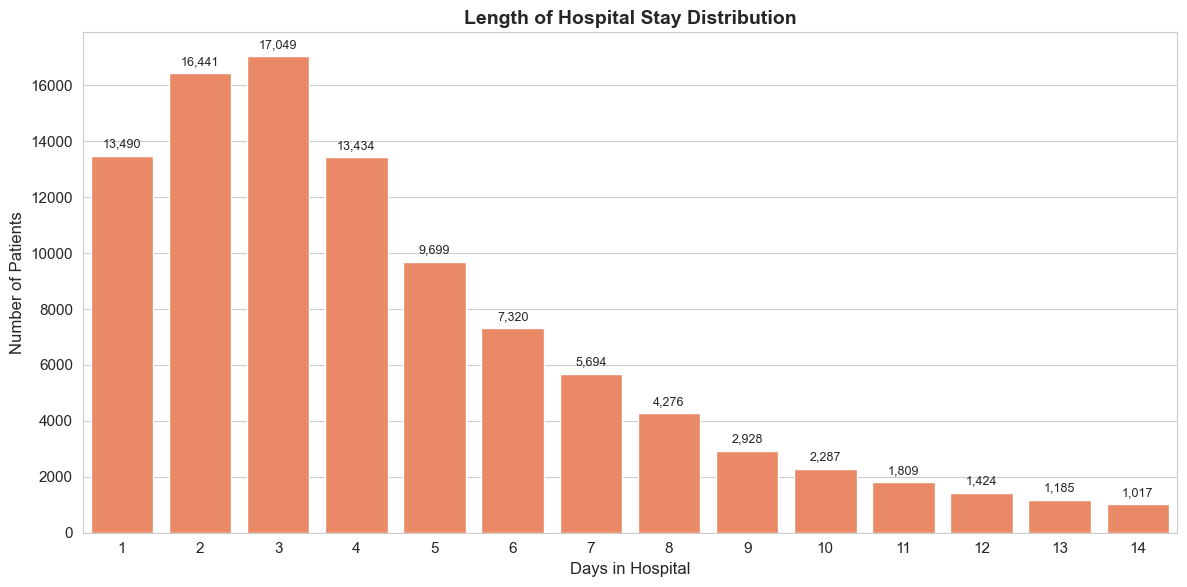


✓ Chart saved to: images/02_length_of_stay.png

Key statistics — Length of Stay:
  • Mean (average): 4.42 days
  • Median (typical): 4 days
  • Most common stay: 3 days (17,049 patients)
  • Maximum stay: 14 days
  • Patients staying 7+ days: 20,620 (21.0%)


In [10]:
# Chart 2: Distribution of length of stay (time in hospital)

plt.figure(figsize=(12, 6))

# Get length of stay counts
los_counts = df['time_in_hospital'].value_counts().sort_index()

# Create the bar chart
ax = sns.barplot(x=los_counts.index, y=los_counts.values, color='coral')

# Titles and labels
plt.title('Length of Hospital Stay Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Days in Hospital', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Add count labels above each bar
for i, v in enumerate(los_counts.values):
    ax.text(i, v + 300, f'{v:,}', ha='center', fontsize=9)

# Save and display
plt.tight_layout()
plt.savefig('../images/02_length_of_stay.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key statistics
print(f"\n✓ Chart saved to: images/02_length_of_stay.png")
print(f"\nKey statistics — Length of Stay:")
print(f"  • Mean (average): {df['time_in_hospital'].mean():.2f} days")
print(f"  • Median (typical): {df['time_in_hospital'].median():.0f} days")
print(f"  • Most common stay: {los_counts.idxmax()} days ({los_counts.max():,} patients)")
print(f"  • Maximum stay: {df['time_in_hospital'].max()} days")
print(f"  • Patients staying 7+ days: {(df['time_in_hospital'] >= 7).sum():,} ({(df['time_in_hospital'] >= 7).mean()*100:.1f}%)")

### 📊 Finding 2: Length of Stay is Right-Skewed with a Clear Acute-Care Peak

**Observation:** The length of hospital stay distribution shows a strong right-skew with most patients receiving short-term acute care:
- **Peak stay: 3 days** (17,049 patients, 17.4% of total)
- **61.7% of patients stay between 1–4 days** (acute / short-term care)
- **Mean stay: 4.42 days** | **Median: 4 days**
- **Long-tail group (7+ days): 20,620 patients (21.0%)** — complex or complicated cases
- **Maximum recorded stay: 14 days** (1,017 patients)

**Clinical context:** This pattern is consistent with typical hospital admissions for diabetes-related complications. Short stays (1–4 days) usually indicate routine procedures, hyperglycemia stabilization, or observation. Stays of 7+ days suggest serious complications — diabetic ketoacidosis (DKA), infections requiring IV antibiotics, surgical interventions, or multi-system involvement. The mean (4.42) being higher than the median (4) confirms the right-skew.

**Implication for the model:**
- `time_in_hospital` is a continuous numeric feature ready to use as-is
- Hypothesis 2 (longer stays → higher readmission risk) will be tested in Section 3
- May engineer `extended_stay` (binary: ≥7 days) for interpretability and dashboard segmentation
- The 21% extended-stay group is a high-risk cohort worth tracking separately

**Implication for the dashboard:**
- Segment patients into three tiers for executive view:
  - **Short Stay (1–3 days):** 47,000+ patients — likely lower-risk routine cases
  - **Medium Stay (4–6 days):** ~30,500 patients — moderate complexity
  - **Extended Stay (7+ days):** 20,620 patients — high-priority intervention target
- The Extended Stay group is the most actionable segment for readmission prevention programs

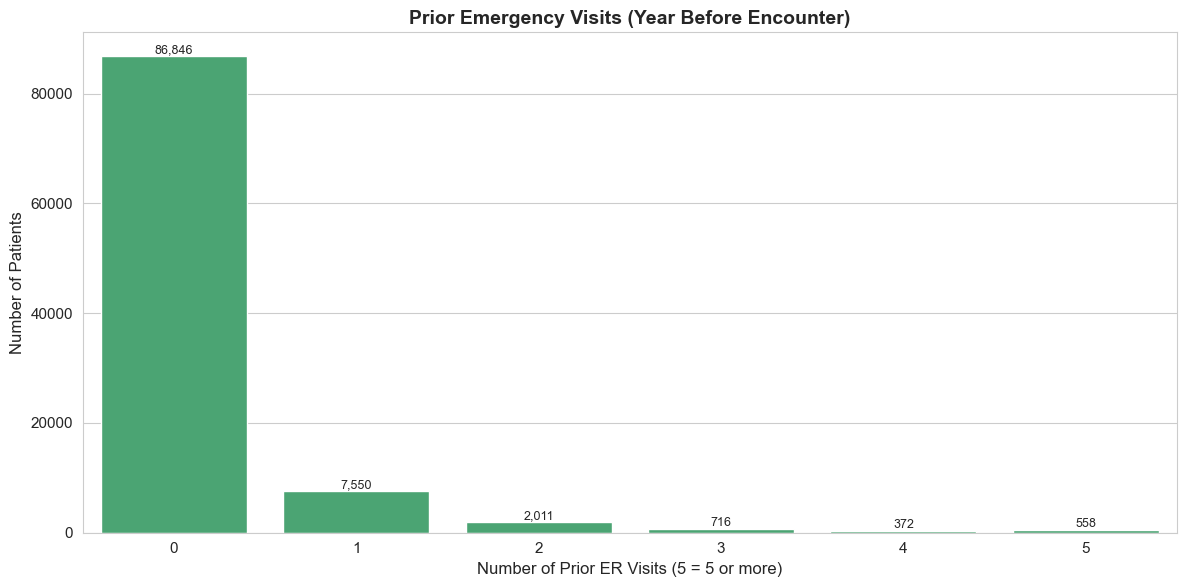


✓ Chart saved to: images/03_prior_emergency_visits.png

Key statistics — Prior Emergency Visits:
  • Patients with 0 prior ER visits: 86,846 (88.6%)
  • Patients with 1+ prior ER visits: 11,207 (11.4%)
  • Patients with 3+ prior ER visits: 1,646 (1.7%)
  • Mean prior ER visits: 0.20
  • Maximum prior ER visits: 76


In [21]:
# Chart 3: Distribution of prior emergency visits

plt.figure(figsize=(12, 6))

# number_emergency = count of ER visits in the year before this encounter
emergency_counts = df['number_emergency'].value_counts().sort_index()

# Most patients have 0; cap the display at 5+ so the chart is readable
emergency_capped = df['number_emergency'].clip(upper=5)
capped_counts = emergency_capped.value_counts().sort_index()

ax = sns.barplot(x=capped_counts.index, y=capped_counts.values, color='mediumseagreen')

plt.title('Prior Emergency Visits (Year Before Encounter)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Prior ER Visits (5 = 5 or more)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

for i, v in enumerate(capped_counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/03_prior_emergency_visits.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved to: images/03_prior_emergency_visits.png")
print(f"\nKey statistics — Prior Emergency Visits:")
print(f"  • Patients with 0 prior ER visits: {(df['number_emergency']==0).sum():,} ({(df['number_emergency']==0).mean()*100:.1f}%)")
print(f"  • Patients with 1+ prior ER visits: {(df['number_emergency']>=1).sum():,} ({(df['number_emergency']>=1).mean()*100:.1f}%)")
print(f"  • Patients with 3+ prior ER visits: {(df['number_emergency']>=3).sum():,} ({(df['number_emergency']>=3).mean()*100:.1f}%)")
print(f"  • Mean prior ER visits: {df['number_emergency'].mean():.2f}")
print(f"  • Maximum prior ER visits: {df['number_emergency'].max()}")

### 📊 Finding 3: Most Patients Have No Prior ER History — But a High-Frequency Tail Exists

**Observation:** Prior emergency-room utilization is extremely right-skewed:
- **88.6% of patients (86,846)** had zero ER visits in the year before this encounter
- **11.4% (11,207)** had at least one prior ER visit
- **Only 1.7% (1,646)** had 3 or more prior ER visits
- **Mean: 0.20 visits** — but the **maximum is 76**, confirming a small group of very high utilizers
- The gap between the mean (0.20) and the max (76) signals extreme outliers, not a smooth distribution

**Clinical context:** Frequent ER use is a well-documented marker of fragmented or unstable care — patients without a reliable primary-care relationship, with poorly controlled chronic conditions, or facing social barriers to access. In readmission research, prior ER visits are consistently one of the strongest predictors of return to the hospital. The small high-frequency tail here (3+ visits) is exactly the cohort clinical literature flags as highest-risk.

**Implication for the model:**
- `number_emergency` is likely to carry strong predictive signal despite most values being zero
- The extreme max (76) means raw values may need handling — consider capping/winsorizing or a binary `frequent_er_user` flag (e.g., ≥2 visits)
- Hypothesis 3 (more prior ER visits → higher readmission) will be tested directly in Section 3 bivariate analysis
- This feature feeds the planned engineered `total_visits` column (outpatient + emergency + inpatient)

**Implication for the dashboard:**
- A "Frequent ER User" segment is a small but high-priority intervention target — likely high readmission rate per patient
- Because the group is small (~1.7% at 3+), interventions here are low-cost to deploy and easy to pilot
- Worth surfacing as its own filter so care teams can pull this list directly

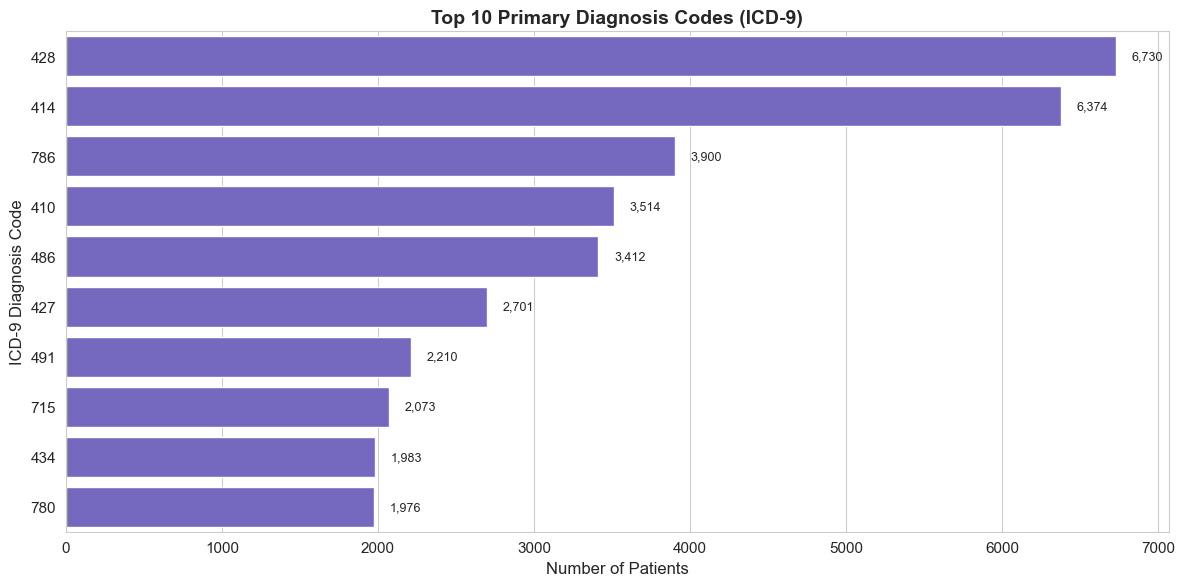


✓ Chart saved to: images/04_top_diagnoses.png

Key statistics — Primary Diagnosis (diag_1):
  • Total unique diagnosis codes: 713
  • Most common code: 428 (6,730 patients)
  • Top 10 codes cover: 34,873 patients (35.6% of all encounters)
  • Remaining 703 codes cover the other 64.4%


In [28]:
# Chart 4: Top 10 primary diagnosis codes (diag_1)

plt.figure(figsize=(12, 6))

# diag_1 holds raw ICD-9 codes — get the 10 most frequent
top_diag = df['diag_1'].value_counts().head(10)

ax = sns.barplot(x=top_diag.values, y=top_diag.index, color='slateblue', orient='h')

plt.title('Top 10 Primary Diagnosis Codes (ICD-9)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Patients', fontsize=12)
plt.ylabel('ICD-9 Diagnosis Code', fontsize=12)

for i, v in enumerate(top_diag.values):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/04_top_diagnoses.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved to: images/04_top_diagnoses.png")
print(f"\nKey statistics — Primary Diagnosis (diag_1):")
print(f"  • Total unique diagnosis codes: {df['diag_1'].nunique():,}")
print(f"  • Most common code: {top_diag.index[0]} ({top_diag.iloc[0]:,} patients)")
print(f"  • Top 10 codes cover: {top_diag.sum():,} patients ({top_diag.sum()/len(df)*100:.1f}% of all encounters)")
print(f"  • Remaining {df['diag_1'].nunique()-10:,} codes cover the other {(1-top_diag.sum()/len(df))*100:.1f}%")

### 📊 Finding 4: Primary Diagnoses Are Cardiovascular-Dominated and Highly Fragmented

**Observation:** Diagnosis data is spread thin across **713 unique ICD-9 codes**, with even the top 10 covering only **35.6% of encounters (34,873 patients)** — the remaining 703 codes account for 64.4%. The top 10:

| ICD-9 | Condition | Patients |
|-------|-----------|----------|
| 428 | Heart failure | 6,730 |
| 414 | Chronic ischemic heart disease | 6,374 |
| 786 | Respiratory / chest symptoms | 3,900 |
| 410 | Acute myocardial infarction | 3,514 |
| 486 | Pneumonia | 3,412 |
| 427 | Cardiac dysrhythmias | 2,701 |
| 491 | Chronic bronchitis | 2,210 |
| 715 | Osteoarthritis | 2,073 |
| 434 | Cerebral artery occlusion (stroke) | 1,983 |
| 780 | General symptoms | 1,976 |

**Clinical context:** Six of the top 10 are cardiovascular or respiratory — and notably, this overlaps directly with the HRRP-tracked conditions (heart failure, AMI, pneumonia, COPD). That overlap matters: the most common reasons patients are admitted here are *exactly* the conditions Medicare penalizes hospitals for when readmissions are high. This is a population where readmission risk is both clinically significant and financially consequential.

**Implication for the model:**
- Raw `diag_1` (713 codes) is far too high-cardinality to one-hot encode — most codes would have tiny sample sizes
- **Required feature-engineering step (Week 3 prep):** group ICD-9 codes into ~9 standard clinical chapters (Circulatory, Respiratory, Diabetes, Injury, etc.) using published ICD-9 chapter mappings — this is on the project plan and not yet done
- Grouped diagnosis category will likely be a meaningful predictor; raw codes would just add noise

**Implication for the dashboard:**
- Executive views should show readmission rate by *diagnosis category*, not raw code — a VP needs "Circulatory" not "428"
- The cardiovascular concentration suggests a natural starting point for a targeted intervention pilot

> ⚠️ **Note:** This chart shows raw ICD-9 codes as a deliberate "what the data looks like" checkpoint. The grouped, executive-readable version is built during feature engineering (Day 7 task) before modeling begins.

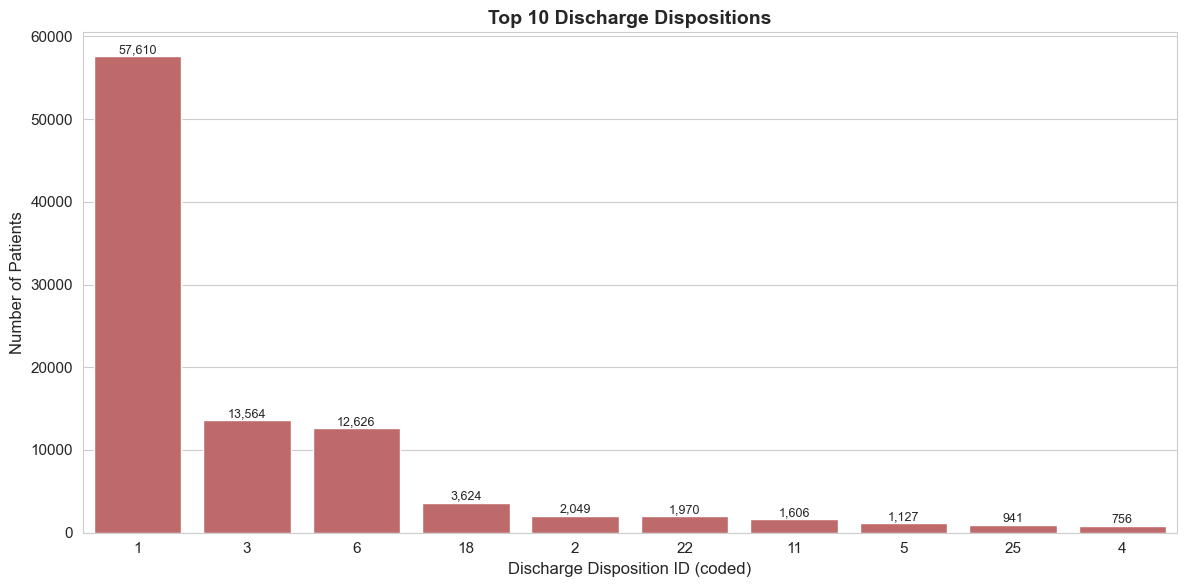


✓ Chart saved to: images/05_discharge_disposition.png

Key statistics — Discharge Disposition:
  • Total unique disposition codes: 26
  • Most common disposition: ID 1 (57,610 patients, 58.8%)
  • Top 3 dispositions cover: 83,800 patients (85.5%)


In [31]:
# Chart 5: Discharge disposition distribution

plt.figure(figsize=(12, 6))

# discharge_disposition_id is a coded number — show the 10 most common
top_discharge = df['discharge_disposition_id'].value_counts().head(10)

ax = sns.barplot(x=top_discharge.index, y=top_discharge.values,
                 color='indianred', order=top_discharge.index)

plt.title('Top 10 Discharge Dispositions', fontsize=14, fontweight='bold')
plt.xlabel('Discharge Disposition ID (coded)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

for i, v in enumerate(top_discharge.values):
    ax.text(i, v + 400, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/05_discharge_disposition.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Chart saved to: images/05_discharge_disposition.png")
print(f"\nKey statistics — Discharge Disposition:")
print(f"  • Total unique disposition codes: {df['discharge_disposition_id'].nunique()}")
print(f"  • Most common disposition: ID {top_discharge.index[0]} ({top_discharge.iloc[0]:,} patients, {top_discharge.iloc[0]/len(df)*100:.1f}%)")
print(f"  • Top 3 dispositions cover: {top_discharge.head(3).sum():,} patients ({top_discharge.head(3).sum()/len(df)*100:.1f}%)")

### 📊 Finding 5: Most Patients Go Straight Home — But Post-Acute Transfers Are a Meaningful Minority

**Observation:** Discharge destination is concentrated but not uniform — 26 unique codes, with the top 3 covering 85.5% of encounters:

| ID | Destination | Patients | % |
|----|-------------|----------|---|
| 1 | Discharged home | 57,610 | 58.8% |
| 3 | Skilled nursing facility (SNF) | 13,564 | 13.8% |
| 6 | Home with home health service | 12,626 | 12.9% |
| 18 | NULL / unknown | 3,624 | 3.7% |
| 2 | Transferred to another short-term hospital | 2,049 | 2.1% |
| 22 | Transferred to rehab facility | 1,970 | 2.0% |
| 11 | Expired (patient died) | 1,606 | 1.6% |
| 5 | Transferred to another inpatient institution | 1,127 | 1.1% |
| 4 | Transferred to intermediate care facility | 756 | 0.8% |

**Clinical context:** While 58.8% of patients are discharged routinely home, roughly **27% require post-acute support** — SNF (13.8%) or home health (12.9%). In readmission research, discharge destination is one of the most reliable risk signals: patients sent to a SNF or home with health services are, by definition, not well enough for an unsupported discharge, and these groups consistently show elevated 30-day return rates. The presence of an "expired" code (ID 11, 1,606 patients) is also important — these encounters cannot be readmitted and may need handling before modeling.

**Implication for the model:**
- `discharge_disposition_id` is likely a strong predictor — Hypothesis 4 will be tested directly in Section 3
- **Data-integrity step before modeling:** encounters with disposition ID 11 (expired) and related codes should be reviewed — a deceased patient has zero readmission risk by definition, and including them can distort the model. The original Strack et al. (2014) study excluded these.
- Will group the 26 codes into a few meaningful buckets (Home, Home+Support, SNF/Rehab, Transferred, Expired/Other) — light feature-engineering, on the plan
- ID 18 (NULL/unknown) and ID 25 (not mapped) should be folded into an "Unknown" category

**Implication for the dashboard:**
- Discharge destination is intuitive for clinicians — a natural primary filter for the risk-scoring view
- The SNF and home-health groups (~27% combined) are a large, well-defined intervention target — care teams already touch these patients at discharge, so adding a risk flag is low-friction

> ⚠️ **Note:** Chart shows raw disposition IDs. Grouped categories and the expired-patient exclusion are handled in feature engineering before modeling.

## Section 3: Feature Engineering

The raw dataset has features that aren't directly usable for modeling — age is stored as text brackets, diagnoses are spread across 713 raw ICD-9 codes, and discharge is 26 separate codes. This section engineers five model-ready features:

1. **`age_midpoint`** — numeric age from bracket text
2. **`total_visits`** — combined prior healthcare utilization
3. **`num_diagnoses`** — count of diagnoses recorded per encounter
4. **`diagnosis_category`** — ICD-9 codes grouped into clinical chapters
5. **`discharge_group`** — discharge dispositions grouped into meaningful buckets

Each feature is documented with the reasoning behind it. These feed both the Section 4 bivariate analysis and the Week 3 predictive model.

In [36]:
# Feature 1: age_midpoint — convert age brackets like '[70-80)' to numeric midpoint (75)

age_midpoint_map = {
    '[0-10)': 5,    '[10-20)': 15,  '[20-30)': 25,  '[30-40)': 35,
    '[40-50)': 45,  '[50-60)': 55,  '[60-70)': 65,  '[70-80)': 75,
    '[80-90)': 85,  '[90-100)': 95
}

df['age_midpoint'] = df['age'].map(age_midpoint_map)

print("✓ Created feature: age_midpoint")
print(f"  • Unique values: {sorted(df['age_midpoint'].unique())}")
print(f"  • Any unmapped (nulls)? {df['age_midpoint'].isnull().sum()}")
print(f"  • Mean patient age (midpoint): {df['age_midpoint'].mean():.1f} years")
print(f"  • Median patient age (midpoint): {df['age_midpoint'].median():.0f} years")

✓ Created feature: age_midpoint
  • Unique values: [5, 15, 25, 35, 45, 55, 65, 75, 85, 95]
  • Any unmapped (nulls)? 0
  • Mean patient age (midpoint): 66.3 years
  • Median patient age (midpoint): 65 years


**Feature 1 — `age_midpoint`**

The original `age` column stores values as text brackets (`[70-80)`). Models can't use text ranges, so each bracket is mapped to its numeric midpoint (`[70-80)` → 75). All 10 brackets mapped cleanly with zero nulls. The resulting mean of 66.3 years confirms the older-skewed population identified in Section 2, Finding 1.

In [41]:
# Feature 2: total_visits — combined prior healthcare utilization
# Sum of outpatient + emergency + inpatient visits in the year before this encounter

df['total_visits'] = (
    df['number_outpatient'] +
    df['number_emergency'] +
    df['number_inpatient']
)

print("✓ Created feature: total_visits")
print(f"  • Mean total prior visits: {df['total_visits'].mean():.2f}")
print(f"  • Median total prior visits: {df['total_visits'].median():.0f}")
print(f"  • Maximum total prior visits: {df['total_visits'].max()}")
print(f"  • Patients with 0 prior visits: {(df['total_visits']==0).sum():,} ({(df['total_visits']==0).mean()*100:.1f}%)")
print(f"  • Patients with 4+ prior visits: {(df['total_visits']>=4).sum():,} ({(df['total_visits']>=4).mean()*100:.1f}%)")

✓ Created feature: total_visits
  • Mean total prior visits: 1.23
  • Median total prior visits: 0
  • Maximum total prior visits: 80
  • Patients with 0 prior visits: 53,126 (54.2%)
  • Patients with 4+ prior visits: 9,867 (10.1%)


In [43]:
# Feature 3: diagnosis complexity
# Note: diag_1/2/3 are all filled (we dropped missing-diagnosis rows in cleaning),
# so counting them = 3 for everyone. Instead we use the dataset's own
# 'number_diagnoses' column, which counts ALL diagnoses entered for the encounter.

# Quick check — confirm diag_1/2/3 counting would be useless:
diag_count_check = df[['diag_1', 'diag_2', 'diag_3']].notna().sum(axis=1)
print(f"Counting diag_1/2/3 — unique values: {sorted(diag_count_check.unique())}")
print("  (All 3 = confirms this would carry no signal)\n")

# Use the dataset's number_diagnoses column instead — rename for clarity
df['num_diagnoses'] = df['number_diagnoses']

print("✓ Created feature: num_diagnoses (from dataset's number_diagnoses)")
print(f"  • Range: {df['num_diagnoses'].min()} to {df['num_diagnoses'].max()} diagnoses")
print(f"  • Mean: {df['num_diagnoses'].mean():.2f}")
print(f"  • Median: {df['num_diagnoses'].median():.0f}")
print(f"  • Patients with 9+ diagnoses: {(df['num_diagnoses']>=9).sum():,} ({(df['num_diagnoses']>=9).mean()*100:.1f}%)")

Counting diag_1/2/3 — unique values: [3]
  (All 3 = confirms this would carry no signal)

✓ Created feature: num_diagnoses (from dataset's number_diagnoses)
  • Range: 3 to 16 diagnoses
  • Mean: 7.51
  • Median: 8
  • Patients with 9+ diagnoses: 48,794 (49.8%)


**Feature 3 — `num_diagnoses`**

Originally planned to count filled `diag_1/2/3` fields — but the Day 4 cleaning step dropped all rows with missing diagnosis codes, so all three are filled for every remaining patient. Counting them would return 3 for everyone and carry no predictive signal (confirmed in the check above).

Instead, this feature uses the dataset's own `number_diagnoses` column, which counts *all* diagnoses entered for the encounter — not just the 3 primary ones. It ranges from 3 to 16 (mean 7.51), and 49.8% of patients have 9+ diagnoses. More diagnoses recorded indicates a more medically complex patient, which is a recognized readmission risk factor.

In [46]:
# Feature 4: diagnosis_category — group raw ICD-9 codes into standard clinical chapters
# ICD-9 chapter ranges are standard; diabetes (250.xx) is broken out separately
# because it sits inside Endocrine but is the clinical focus of this dataset.

def categorize_diagnosis(code):
    code = str(code)
    # V-codes and E-codes: supplementary classifications
    if code.startswith('V'):
        return 'Other (V-code)'
    if code.startswith('E'):
        return 'Injury / External'
    # Convert to numeric (integer part) for chapter ranges
    try:
        num = float(code)
    except ValueError:
        return 'Other'
    # Diabetes broken out first (250.xx) — clinical focus of this dataset
    if 250 <= num < 251:
        return 'Diabetes'
    # Standard ICD-9 chapter ranges
    if   1   <= num <= 139: return 'Infectious'
    elif 140 <= num <= 239: return 'Neoplasms'
    elif 240 <= num <= 279: return 'Endocrine / Metabolic'
    elif 280 <= num <= 289: return 'Blood'
    elif 290 <= num <= 319: return 'Mental'
    elif 320 <= num <= 389: return 'Nervous / Sensory'
    elif 390 <= num <= 459: return 'Circulatory'
    elif 460 <= num <= 519: return 'Respiratory'
    elif 520 <= num <= 579: return 'Digestive'
    elif 580 <= num <= 629: return 'Genitourinary'
    elif 630 <= num <= 679: return 'Pregnancy / Childbirth'
    elif 680 <= num <= 709: return 'Skin'
    elif 710 <= num <= 739: return 'Musculoskeletal'
    elif 740 <= num <= 759: return 'Congenital'
    elif 760 <= num <= 779: return 'Perinatal'
    elif 780 <= num <= 799: return 'Symptoms / Ill-defined'
    elif 800 <= num <= 999: return 'Injury / External'
    else: return 'Other'

df['diagnosis_category'] = df['diag_1'].apply(categorize_diagnosis)

print("✓ Created feature: diagnosis_category")
print(f"  • Raw codes reduced: 713 unique → {df['diagnosis_category'].nunique()} categories\n")
print("Distribution (most common first):")
cat_counts = df['diagnosis_category'].value_counts()
for cat, count in cat_counts.items():
    print(f"  • {cat:<26} {count:>7,}  ({count/len(df)*100:>5.1f}%)")

✓ Created feature: diagnosis_category
  • Raw codes reduced: 713 unique → 18 categories

Distribution (most common first):
  • Circulatory                 29,530  ( 30.1%)
  • Respiratory                 10,093  ( 10.3%)
  • Digestive                    8,928  (  9.1%)
  • Diabetes                     7,965  (  8.1%)
  • Symptoms / Ill-defined       7,427  (  7.6%)
  • Injury / External            6,704  (  6.8%)
  • Genitourinary                4,947  (  5.0%)
  • Musculoskeletal              4,739  (  4.8%)
  • Neoplasms                    3,312  (  3.4%)
  • Infectious                   2,689  (  2.7%)
  • Endocrine / Metabolic        2,592  (  2.6%)
  • Skin                         2,438  (  2.5%)
  • Mental                       2,145  (  2.2%)
  • Other (V-code)               1,600  (  1.6%)
  • Nervous / Sensory            1,170  (  1.2%)
  • Blood                        1,079  (  1.1%)
  • Pregnancy / Childbirth         645  (  0.7%)
  • Congenital                      50  (  0

**Feature 4 — `diagnosis_category`**

The raw `diag_1` column held **713 unique ICD-9 codes** — far too high-cardinality to use directly in a model. This feature groups them into **18 standard clinical chapters** using documented ICD-9 chapter ranges (e.g. 390–459 = Circulatory, 460–519 = Respiratory).

Two deliberate mapping decisions:
- **Diabetes (250.xx) is broken out as its own category** rather than left inside the Endocrine chapter (240–279). Since this is a diabetes patient dataset, treating diabetes as a distinct group preserves clinically meaningful signal.
- **V-codes and E-codes** (supplementary classifications) are handled separately — V-codes to "Other (V-code)", E-codes folded into "Injury / External".

The result aligns with Chart 4: **Circulatory dominates at 30.1%**, followed by Respiratory (10.3%), Digestive (9.1%), and Diabetes (8.1%). The "Other (V-code)" bucket is only 1.6%, confirming the mapping captured nearly all codes cleanly. This grouped feature replaces raw `diag_1` for both bivariate analysis and modeling.

In [49]:
# Feature 5: discharge_group — group 26 discharge disposition codes into meaningful buckets
# Disposition IDs are defined in the dataset's IDS_mapping.csv

def categorize_discharge(disp_id):
    # Discharged home, no support
    if disp_id == 1:
        return 'Home'
    # Discharged home WITH support services
    elif disp_id in [6, 8]:
        return 'Home + Support'
    # Skilled nursing / rehab / intermediate care facilities
    elif disp_id in [3, 4, 5, 22, 23, 24]:
        return 'SNF / Rehab / Care Facility'
    # Transferred to another hospital / inpatient institution
    elif disp_id in [2, 9, 10, 15, 27, 28, 29]:
        return 'Transferred to Hospital'
    # Patient died
    elif disp_id in [11, 19, 20, 21]:
        return 'Expired'
    # Hospice
    elif disp_id in [13, 14]:
        return 'Hospice'
    # Unknown / null / not mapped / left AMA / still patient
    else:
        return 'Unknown / Other'

df['discharge_group'] = df['discharge_disposition_id'].apply(categorize_discharge)

print("✓ Created feature: discharge_group")
print(f"  • Raw codes reduced: 26 unique → {df['discharge_group'].nunique()} groups\n")
print("Distribution (most common first):")
disch_counts = df['discharge_group'].value_counts()
for grp, count in disch_counts.items():
    print(f"  • {grp:<32} {count:>7,}  ({count/len(df)*100:>5.1f}%)")

✓ Created feature: discharge_group
  • Raw codes reduced: 26 unique → 7 groups

Distribution (most common first):
  • Home                              57,610  ( 58.8%)
  • SNF / Rehab / Care Facility       17,865  ( 18.2%)
  • Home + Support                    12,732  ( 13.0%)
  • Unknown / Other                    5,185  (  5.3%)
  • Transferred to Hospital            2,281  (  2.3%)
  • Expired                            1,616  (  1.6%)
  • Hospice                              764  (  0.8%)


**Feature 5 — `discharge_group`**

The raw `discharge_disposition_id` column had **26 distinct codes** — too granular and many with tiny sample sizes. This feature groups them into **7 clinically meaningful buckets** using the definitions in the dataset's `IDS_mapping.csv`:

| Group | % | What it captures |
|-------|---|------------------|
| Home | 58.8% | Routine discharge, no support |
| SNF / Rehab / Care Facility | 18.2% | Post-acute facility care |
| Home + Support | 13.0% | Home with health services |
| Unknown / Other | 5.3% | Null, not mapped, left AMA, still patient |
| Transferred to Hospital | 2.3% | Moved to another inpatient institution |
| Expired | 1.6% | Patient died during encounter |
| Hospice | 0.8% | End-of-life care |

The ~31% in post-acute support (SNF/Rehab + Home+Support) is a well-defined, high-risk intervention target. The "Expired" and "Hospice" groups (2.4% combined) flag encounters that cannot meaningfully readmit — handled before modeling.

In [52]:
# Save the dataset with engineered features
output_path = '../data/processed/cleaned_data_features.csv'
df.to_csv(output_path, index=False)

print(f"✓ Dataset with engineered features saved to: {output_path}")
print(f"  • Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  • New features added: age_midpoint, total_visits, num_diagnoses, diagnosis_category, discharge_group")

✓ Dataset with engineered features saved to: ../data/processed/cleaned_data_features.csv
  • Shape: 98,053 rows × 54 columns
  • New features added: age_midpoint, total_visits, num_diagnoses, diagnosis_category, discharge_group


In [54]:
# Section 3 summary — feature engineering complete
print("=" * 60)
print("SECTION 3 COMPLETE — FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print()
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns (5 new features)")
print()
print("Features engineered:")
print("  1. age_midpoint        — numeric age from bracket text")
print("  2. total_visits        — combined prior healthcare utilization")
print("  3. num_diagnoses       — diagnosis complexity per encounter")
print("  4. diagnosis_category  — 713 ICD-9 codes grouped into 18 chapters")
print("  5. discharge_group     — 26 disposition codes grouped into 7 buckets")
print()
print("Saved to: data/processed/cleaned_data_features.csv")
print("Ready for Section 4: Bivariate Analysis (features vs readmission)")
print("=" * 60)

SECTION 3 COMPLETE — FEATURE ENGINEERING SUMMARY

Dataset shape: 98,053 rows × 54 columns (5 new features)

Features engineered:
  1. age_midpoint        — numeric age from bracket text
  2. total_visits        — combined prior healthcare utilization
  3. num_diagnoses       — diagnosis complexity per encounter
  4. diagnosis_category  — 713 ICD-9 codes grouped into 18 chapters
  5. discharge_group     — 26 disposition codes grouped into 7 buckets

Saved to: data/processed/cleaned_data_features.csv
Ready for Section 4: Bivariate Analysis (features vs readmission)
